Pasos:
* 0- Importar paqueterías y leer archivos
* 1- Revisamos si hay nulos y también el tipo de datos que tenemos
* 2- Primeras transformaciones de los datos (modificar fechas y quitar columnas id)
* 3- Analisis del primario de las columnas y serie de tiempo
* 4- Tratamiento de datos continuos (Aplicamos logaritmo a monto y rellenamos na's)
* 5- Dummies 
* 6- PCA y escalado
* 7- Agrupacion
* 8- Modelado (DB-SCAN y Isolation Forest)
* 9- Conclusiones basadas en estadistica

### 0 -Importacion de paqueterias y lectura de archivo

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import math
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN


In [3]:
Ruta_Data = 'C:/Users/jesus/OneDrive/Escritorio/MELI_PRUEBA'
Archivo_Fraude = pd.read_csv(f'{Ruta_Data}/CASO2.csv')

KeyboardInterrupt: 

In [ ]:
print("# de elementos del DF:",len(Archivo_Fraude))
print("# de columnas del DF:",len(Archivo_Fraude.columns))
Archivo_Fraude.head()

# de elementos del DF: 1978193
# de columnas del DF: 20


,CUENTA_ID_HASH,NO_IDENTIFACION_HASH,ENTIDAD_FEDERATIVA,CALLE_HASH,COLONIA_HASH,CODIGO_POSTAL_HASH,EDAD,KYC_PRIMARY_ACTIVITY_CODE,OCUPACION,FECHA_INICIO_RELACION,FLUJO,MOVIMIENTO,CONTRAPARTE_HASH,TRX_ID_HASH,PAY_TOTAL_PAID_AMT,PAY_CREATED_DATETIME,SERVICIO,PAY_OPERATION_TYPE_ID,PAY_PAYMENT_METHOD_TYPE_ID,PAY_PAYMENT_METHOD_ID
0,7XekbI5Po694x9Ee7qOaQ1AzwUSV56YKVmmBGiqOJUs=,xVS0fHvU0Kn43N0Iu323927rS94IxLsH5pHzx/4m8Xw=,Distrito Federal,nxQCWvAGWzDkfiPrs7SR05ro7RfTNznl/zgn/7NjSVM=,Un/D/JaNKBnDg97j6h/NsUxgxs2TEa79wNWKkIeHc0w=,3ttiutosBOzg5VyEnlrigIxxxwS+EK8tbPTl1qQSbic=,38.0,NaN,PARTNEROROWNER,2023-12-10 20:35:01,ENTRADAS,Ingreso por procesamiento de pagos,HDjMX3tDbaKUoxTEezJ/y8z6u2At8t+huqzgFlcq+IU=,vvMpi2y9YnuCFhLUgpyp0+k49XBL3NhcppDNTchEHto=,596.00,2024-12-27 17:35:49,POINT,pos_payment,debit_card,debvisa
1,ZYBU9DO1jKccpMSUfc1V8FfNVp6kPcrx08qz3XU44rY=,JuyN0lH1HOpxIrvFH/Rm0UBShCWiCMGJycB2IXItkXc=,Tabasco,pWoStCadLq84l6iHhFzyzjEemGLSUEnUn4PaI4M0P38=,TNJrUL6Op1UfzMA+2sqqwnLArSJdagd4+EQDBhvay+Q=,dTfxl1WNzpaJz2DRZ+CeSGsL46lkvaDM8QIYbbP4ci0=,28.0,NaN,OWNBUSINESS,2022-06-29 14:26:07,ENTRADAS,Money in vía P2P,DQpbkR6MyYHbsdeTGh6puK/tp7jjJXV8Q6o6sdoN5Xs=,8HgtYO5he2Nb6JpsBlzejC2TbE79XEaPOwQTp/gaHjI=,0.02,2024-12-04 03:28:54,TRANSFERENCIA_DINERO_CUENTA,money_transfer,account_money,account_money
2,MEZz2qn1z/kusnIEP+v+t6IMznhRSiymBRs/rBPBNLI=,/TYl+xaqfbXzfKNiwv3OuYDqmnhFuU8fGldlaypoMMU=,Guanajuato,YGWqLIcCz4El4DYmYNym3t7t1LOtzs/WJaBsm2O7btQ=,iPBPsg+OgXmKeudCVY2HNQ7GvWaA2PICh2w66o+jmOI=,4PczORUKPENCIjcRQv4x0x6/9zOjXRfuvtGwwVAc+g0=,68.0,NaN,PARTNEROROWNER,2023-11-09 20:08:44,ENTRADAS,Money in vía P2P,DQpbkR6MyYHbsdeTGh6puK/tp7jjJXV8Q6o6sdoN5Xs=,5kmLZfTPGl80tK9AS0K9o4II9PnTa5Gkv+h5/sOhLNM=,0.05,2024-07-03 05:17:00,TRANSFERENCIA_DINERO_CUENTA,money_transfer,account_money,account_money
3,4FE6bl+5BymcNZ48ryR/AJ/y8Thl4yvwfggINmi/NEs=,1W2J+VPjcvInx6Zg3EVMTesrwd819Oh8vnUrsA8+/24=,San Luis Potosí,4ue2SUfPdqp8DWH8VLn4MoKKCI03mleb6SvGvdRWfq4=,yrcOQY9/2GzdFP4lVQqPc7AC8wDpvIi2e6yMMPPu4ww=,nq5pER10YP6lQlI8fYy6tCJQhzcv0pz8L8I5b42VCm0=,19.0,NaN,STUDENT,2023-12-18 18:35:46,SALIDAS,Money out (Clabe),ITpiu6NmdwtaGNvfviBQe1piS5TXfXDORyjMcFyHrBY=,Cl0LdQJpzYM+BDvRpp3MBV1EVVcp5UXaAZ7E81bLsUA=,400.00,2024-01-17 23:10:56,PAYOUT_TRANSFER,transfer,online,NaN
4,nwYbGSSXoo7l6Tmlgm1dQGdcTPGrnb/DDEGrSY5nSsY=,z+j2Mp0zjrtImhxS00NuEfvwGaqliVNYEqy46xzA6Zs=,Coahuila,45KB3OJ9CyjwGQhZJF04kG0PzlhOo8sU0hEcLJaFkDQ=,bnuOerZzhb2Vspi1APjsyTcUcmJwB8Vb2NQLlsdH8WQ=,SPWWrSIkVf7mjiYNXb0+xsYZLJ4SvukV4GqJBPKMu6w=,26.0,NaN,HOUSEKEEPER,2023-03-10 13:02:03,ENTRADAS,Money in vía transferencia (Clabe),NaN,L0QzRqKCwCZj/PiKTONnzvx2dGi6P/1cPb62jUVhAmE=,1000.00,2024-04-28 13:13:30,FONDEO_CLABE,account_fund,bank_transfer,clabe


In [ ]:
print(Archivo_Fraude.columns)

Index(['CUENTA_ID_HASH', 'NO_IDENTIFACION_HASH', 'ENTIDAD_FEDERATIVA',
       'CALLE_HASH', 'COLONIA_HASH', 'CODIGO_POSTAL_HASH', 'EDAD',
       'KYC_PRIMARY_ACTIVITY_CODE', 'OCUPACION', 'FECHA_INICIO_RELACION',
       'FLUJO', 'MOVIMIENTO', 'CONTRAPARTE_HASH', 'TRX_ID_HASH',
       'PAY_TOTAL_PAID_AMT', 'PAY_CREATED_DATETIME', 'SERVICIO',
       'PAY_OPERATION_TYPE_ID', 'PAY_PAYMENT_METHOD_TYPE_ID',
       'PAY_PAYMENT_METHOD_ID'],
      dtype='object')


### 1 -Revisamos los nulos y observamos que tipo de datos existen en nuestro conjunto:

In [ ]:
Archivo_Fraude.isnull().any().any()
# Con este true comprobamos que si hay datos nulos en la base de datos. Habrá que hacerse un analisis para ver porque existen estos nulos

True

In [ ]:
Archivo_Fraude.isnull().any().value_counts()
# Contamos con 19 columnas de nulos.

True     19
False     1
Name: count, dtype: int64

In [ ]:
Archivo_Fraude.columns[Archivo_Fraude.isnull().any()==False]
# Caracteristicas sin nulos

Index(['CUENTA_ID_HASH'], dtype='object')

In [ ]:
Archivo_Fraude.columns[Archivo_Fraude.isnull().any()==True]
# Caracteristicas con  nulos

Index(['NO_IDENTIFACION_HASH', 'ENTIDAD_FEDERATIVA', 'CALLE_HASH',
       'COLONIA_HASH', 'CODIGO_POSTAL_HASH', 'EDAD',
       'KYC_PRIMARY_ACTIVITY_CODE', 'OCUPACION', 'FECHA_INICIO_RELACION',
       'FLUJO', 'MOVIMIENTO', 'CONTRAPARTE_HASH', 'TRX_ID_HASH',
       'PAY_TOTAL_PAID_AMT', 'PAY_CREATED_DATETIME', 'SERVICIO',
       'PAY_OPERATION_TYPE_ID', 'PAY_PAYMENT_METHOD_TYPE_ID',
       'PAY_PAYMENT_METHOD_ID'],
      dtype='object')

In [ ]:
Archivo_Fraude.info()
# Hasta abajo podemos ver un resumen de cuantas variables del tipo objeto hay y cuantas del tipo flotante hay

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1978193 entries, 0 to 1978192
Data columns (total 20 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   CUENTA_ID_HASH              object 
 1   NO_IDENTIFACION_HASH        object 
 2   ENTIDAD_FEDERATIVA          object 
 3   CALLE_HASH                  object 
 4   COLONIA_HASH                object 
 5   CODIGO_POSTAL_HASH          object 
 6   EDAD                        float64
 7   KYC_PRIMARY_ACTIVITY_CODE   object 
 8   OCUPACION                   object 
 9   FECHA_INICIO_RELACION       object 
 10  FLUJO                       object 
 11  MOVIMIENTO                  object 
 12  CONTRAPARTE_HASH            object 
 13  TRX_ID_HASH                 object 
 14  PAY_TOTAL_PAID_AMT          float64
 15  PAY_CREATED_DATETIME        object 
 16  SERVICIO                    object 
 17  PAY_OPERATION_TYPE_ID       object 
 18  PAY_PAYMENT_METHOD_TYPE_ID  object 
 19  PAY_PAYMENT_METHOD_ID

In [ ]:
# Creamos listas con los tipos de datos
Columnas_Objetos = Archivo_Fraude.columns[Archivo_Fraude.dtypes=='object']
Columnas_Continuos = Archivo_Fraude.columns[Archivo_Fraude.dtypes=='float64']
len(Columnas_Continuos)+len(Columnas_Objetos) == len(Archivo_Fraude.columns)

True

In [ ]:
Archivo_Fraude[Columnas_Objetos].nunique()

CUENTA_ID_HASH                  21201
NO_IDENTIFACION_HASH            21156
ENTIDAD_FEDERATIVA                 32
CALLE_HASH                      16315
COLONIA_HASH                    12451
CODIGO_POSTAL_HASH               7808
KYC_PRIMARY_ACTIVITY_CODE          89
OCUPACION                          10
FECHA_INICIO_RELACION           20884
FLUJO                               2
MOVIMIENTO                         14
CONTRAPARTE_HASH               281371
TRX_ID_HASH                   1970426
PAY_CREATED_DATETIME          1857175
SERVICIO                           34
PAY_OPERATION_TYPE_ID               9
PAY_PAYMENT_METHOD_TYPE_ID          9
PAY_PAYMENT_METHOD_ID              22
dtype: int64

### 2- Transformacion de datos
*  Cambiaremos la fecha a dia, año, mes, segundos, etc. Tanto para la transferencia tanto como para el inicio de relacion

In [ ]:
Archivo_Fraude['FECHA_INICIO_RELACION'] = pd.to_datetime(Archivo_Fraude['FECHA_INICIO_RELACION'])
Archivo_Fraude['año_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.year
Archivo_Fraude['mes_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.month
Archivo_Fraude['dia_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.day
Archivo_Fraude['hora_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.hour
Archivo_Fraude['dia_semana_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.weekday
Archivo_Fraude['semana_INICIO_RELACION'] = Archivo_Fraude['FECHA_INICIO_RELACION'].dt.isocalendar().week

In [ ]:
Archivo_Fraude['PAY_CREATED_DATETIME'] = pd.to_datetime(Archivo_Fraude['PAY_CREATED_DATETIME'])
Archivo_Fraude['año_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.year
Archivo_Fraude['mes_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.month
Archivo_Fraude['dia_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.day
Archivo_Fraude['hora_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.hour
Archivo_Fraude['minutos_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.minute
Archivo_Fraude['semana_Transaccion'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.isocalendar().week

In [ ]:
Archivo_Fraude['PAY_CREATED_DATETIME'] = Archivo_Fraude['PAY_CREATED_DATETIME'].dt.date
df_diario = pd.pivot_table(Archivo_Fraude,values='PAY_TOTAL_PAID_AMT',index='PAY_CREATED_DATETIME', aggfunc= 'sum',dropna=False)
df_diario

,PAY_TOTAL_PAID_AMT
PAY_CREATED_DATETIME,
2024-01-01,1614042.72
2024-01-02,3253601.24
2024-01-03,2618140.18
2024-01-04,2665231.42
2024-01-05,2912761.81
...,...
2024-12-28,4671158.86
2024-12-29,3561441.03
2024-12-30,6513145.68


### 3 Primeros cruces individual de las columnas

In [ ]:
df_diario = pd.pivot_table(Archivo_Fraude,values='PAY_TOTAL_PAID_AMT',index='PAY_CREATED_DATETIME', aggfunc= 'sum',dropna=True)

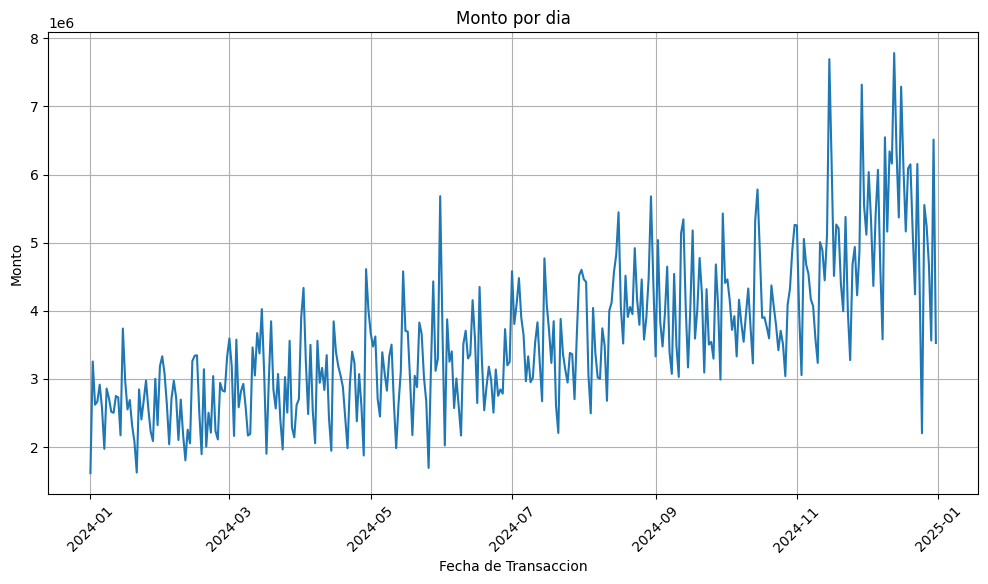

In [ ]:
# Graficar la serie de tiempo agregada por día
plt.figure(figsize=(12, 6))
plt.plot(df_diario.index, df_diario['PAY_TOTAL_PAID_AMT'], linestyle='-')
plt.title('Monto por dia')
plt.xlabel('Fecha de Transaccion')
plt.ylabel('Monto')
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [ ]:
print("Porcentaje de elemento mayores a 3 veces la mediana:",round(100*len(Archivo_Fraude[Archivo_Fraude['PAY_TOTAL_PAID_AMT']>=3*Archivo_Fraude['PAY_TOTAL_PAID_AMT'].median()])/len(Archivo_Fraude),1),"%")

Porcentaje de elemento mayores a 3 veces la mediana: 28.8 %


In [ ]:
# AG es de analisis general
# Quitamos tantas columnas porque no considero utiles para la segmentacion
Archivo_Fraude_AG = Archivo_Fraude.copy()
Archivo_Fraude_AG = Archivo_Fraude_AG.drop(columns = ['CONTRAPARTE_HASH','TRX_ID_HASH','CUENTA_ID_HASH', 'NO_IDENTIFACION_HASH','PAY_CREATED_DATETIME','FECHA_INICIO_RELACION','CALLE_HASH','COLONIA_HASH','KYC_PRIMARY_ACTIVITY_CODE','CODIGO_POSTAL_HASH'])
Columnas_Objetos = Archivo_Fraude_AG.columns[Archivo_Fraude_AG.dtypes=='object']

In [ ]:
# Numero de elementos unicos por categoría
Archivo_Fraude_AG[Columnas_Objetos].nunique()

ENTIDAD_FEDERATIVA            32
OCUPACION                     10
FLUJO                          2
MOVIMIENTO                    14
SERVICIO                      34
PAY_OPERATION_TYPE_ID          9
PAY_PAYMENT_METHOD_TYPE_ID     9
PAY_PAYMENT_METHOD_ID         22
dtype: int64

## Desicion:
Como el poder computcional no es suficiente para aplicar dummies a todos las columnas a nivel transaccion tenemos varias opciones:
* Utilizar Apache Spark para incrementar el poder computacional
* Hacer particiones del data set.
* Trabajar con una muestra representativa
* No usar dummies: Considero necesario usar dummies ya que no conozco bien las variables
* Agrupar por cliente.
* Eliminar algunas columnas

### 4- Tratamiento de datos contínuos

In [ ]:
round(Archivo_Fraude_AG[Columnas_Continuos].describe(),1)

,EDAD,PAY_TOTAL_PAID_AMT
count,1915093.0,1970495.0
mean,35.2,669.6
std,10.9,3650.2
min,18.0,0.0
25%,27.0,15.0
50%,33.0,119.0
75%,42.0,433.0
max,88.0,1462200.0


In [ ]:
Archivo_Fraude_AG[Columnas_Continuos].isnull().any()

EDAD                  True
PAY_TOTAL_PAID_AMT    True
dtype: bool

Rellenaremos la edad con la mediana. Sin embargo le pondremos un flag para los nulos
Para el monto como no sé que implicaciones tiene que esté vacio el dato o que signifique eso, pero como no estoy 100% seguro del contexto rellenaré con el promedio y le pondré una flag

In [ ]:
Archivo_Fraude_AG['Edad_Nula'] = np.where(Archivo_Fraude_AG['EDAD'].isnull(),1,0)
Archivo_Fraude_AG['Monto_NULO'] = np.where(Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'].isnull(),1,0)

In [ ]:
Archivo_Fraude_AG['EDAD'] = np.where(Archivo_Fraude_AG['EDAD'].isnull(),Archivo_Fraude_AG['EDAD'].median(),Archivo_Fraude_AG['EDAD'])
Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'] = np.where(Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'].isnull(),Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'].mean(),Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'])

In [ ]:
# Comprobamos que ya no hay nulos
Archivo_Fraude_AG[Columnas_Continuos].isnull().any()

EDAD                  False
PAY_TOTAL_PAID_AMT    False
dtype: bool

In [ ]:
Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'] = np.log1p(Archivo_Fraude_AG['PAY_TOTAL_PAID_AMT'])

### 5 -Dummies

In [ ]:
Archivo_Fraude_AG_T_1 = pd.get_dummies(Archivo_Fraude_AG,columns=Columnas_Objetos,dummy_na=True,dtype=int)

In [ ]:
columnas_dummies = Archivo_Fraude_AG_T_1.columns[len(Archivo_Fraude_AG.columns)-len(Archivo_Fraude_AG_T_1.columns)-8:]

Quitamos los ultimos nulos

In [ ]:
Columnas_nulas = Archivo_Fraude_AG_T_1.columns[Archivo_Fraude_AG_T_1.isnull().any()]
Archivo_Fraude_AG_T_1[Columnas_nulas].dtypes

año_INICIO_RELACION           float64
mes_INICIO_RELACION           float64
dia_INICIO_RELACION           float64
hora_INICIO_RELACION          float64
dia_semana_INICIO_RELACION    float64
semana_INICIO_RELACION         UInt32
año_Transaccion               float64
mes_Transaccion               float64
dia_Transaccion               float64
hora_Transaccion              float64
minutos_Transaccion           float64
semana_Transaccion             UInt32
dtype: object

In [ ]:
# Rellenamos los datos faltantes con la mediana
for i in Columnas_nulas:
    Archivo_Fraude_AG_T_1[i] = Archivo_Fraude_AG_T_1[i].astype('float64')
    Mediana = Archivo_Fraude_AG_T_1[i].median()
    Archivo_Fraude_AG_T_1[i].fillna(Mediana, inplace=True)

### 6- PCA

In [ ]:
Componentes = 2
pca = PCA(n_components=Componentes) 

Archivo_Fraude_T_2 = pca.fit_transform(Archivo_Fraude_AG_T_1)
lista_componente = []
for i in range(1,Componentes+1):
    lista_componente.append(f'Componente_{i}')
# 3. Crear un DataFrame con los resultados de PCA
pca_df = pd.DataFrame(data=Archivo_Fraude_T_2, columns=lista_componente)

### 6.5- Escalado

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_df)

In [ ]:
scaled_df = pd.DataFrame(data=X_scaled, columns=lista_componente)
scaled_df['CUENTA_ID_HASH'] = Archivo_Fraude['CUENTA_ID_HASH']

### 7- Agrupacion

In [ ]:
Tabla_dinamica_Comp_1_tot =  pd.pivot_table(scaled_df,values='Componente_1',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'Componente_1':'Total_Comp_1'})
Tabla_dinamica_Comp_1_mean =  pd.pivot_table(scaled_df,values='Componente_1',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False).rename(columns={'Componente_1':'Media_Comp_1'})
Tabla_dinamica_Comp_1_Rec =  pd.pivot_table(scaled_df,values='Componente_1',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'Componente_1':'Rec_Trans'})
Tabla_dinamica_Comp_1_max =  pd.pivot_table(scaled_df,values='Componente_1',index='CUENTA_ID_HASH',aggfunc= 'max',dropna=False).rename(columns={'Componente_1':'Max_Comp_1'})
Tabla_dinamica_Comp_1_min =  pd.pivot_table(scaled_df,values='Componente_1',index='CUENTA_ID_HASH',aggfunc= 'min',dropna=False).rename(columns={'Componente_1':'Min_Comp_1'})

In [ ]:
Tabla_dinamica_Comp_2_tot =  pd.pivot_table(scaled_df,values='Componente_2',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'Componente_2':'Total_Comp_2'})
Tabla_dinamica_Comp_2_mean =  pd.pivot_table(scaled_df,values='Componente_2',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False).rename(columns={'Componente_2':'Media_Comp_2'})
Tabla_dinamica_Comp_2_Rec =  pd.pivot_table(scaled_df,values='Componente_2',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'Componente_2':'Rec_Trans'})
Tabla_dinamica_Comp_2_max =  pd.pivot_table(scaled_df,values='Componente_2',index='CUENTA_ID_HASH',aggfunc= 'max',dropna=False).rename(columns={'Componente_2':'Max_Comp_2'})
Tabla_dinamica_Comp_2_min =  pd.pivot_table(scaled_df,values='Componente_2',index='CUENTA_ID_HASH',aggfunc= 'min',dropna=False).rename(columns={'Componente_2':'Min_Comp_2'})

In [ ]:
Lista_DF = [Tabla_dinamica_Comp_1_mean,Tabla_dinamica_Comp_1_Rec,
Tabla_dinamica_Comp_1_max,Tabla_dinamica_Comp_1_min,Tabla_dinamica_Comp_2_tot,Tabla_dinamica_Comp_2_mean,
Tabla_dinamica_Comp_2_Rec,Tabla_dinamica_Comp_2_max,Tabla_dinamica_Comp_2_min]

df_Agrupado = Tabla_dinamica_Comp_1_tot

for i in range(0,len(Lista_DF)):
    df_Agrupado = pd.merge(df_Agrupado, Lista_DF[i], on='CUENTA_ID_HASH', how='left')

In [ ]:
Componentes = 2
pca = PCA(n_components=Componentes) 

df_Agrupado_2 = pca.fit_transform(df_Agrupado)
lista_componente = []
for i in range(1,Componentes+1):
    lista_componente.append(f'Componente_{i}')
# 3. Crear un DataFrame con los resultados de PCA
pca_df_2 = pd.DataFrame(data=df_Agrupado_2, columns=lista_componente)

############################################################# Escalado

X_scaled_2 = scaler.fit_transform(pca_df_2)
scaled_df_V2 = pd.DataFrame(data=X_scaled_2, columns=lista_componente)

### 8 -Modelado

In [ ]:
# Tomamos el 1% de los datos como el mínimo para generar un cluster
dbscan = DBSCAN(eps=0.1, min_samples=math.ceil(len(pca_df_2)/100))  
dbscan_labels = dbscan.fit_predict(scaled_df_V2)

In [ ]:
scaled_df_V2['DBSCAN_Label'] = dbscan_labels
scaled_df_V2['DBSCAN_Label'].value_counts()

DBSCAN_Label
 0    18821
-1     2380
Name: count, dtype: int64

In [ ]:
scaled_df_V2[scaled_df_V2['DBSCAN_Label'] == -1].describe().round(1)

,Componente_1,Componente_2,DBSCAN_Label
count,2380.0,2380.0,2380.0
mean,1.0,0.6,-1.0
std,2.8,2.9,0.0
min,-0.1,-50.1,-1.0
25%,0.2,-0.2,-1.0
50%,0.4,0.6,-1.0
75%,0.8,1.1,-1.0
max,77.0,52.1,-1.0


In [ ]:
scaled_df_V2[scaled_df_V2['DBSCAN_Label'] == 0].describe().round(1)

,Componente_1,Componente_2,DBSCAN_Label
count,18821.0,18821.0,18821.0
mean,-0.1,-0.1,0.0
std,0.1,0.2,0.0
min,-0.2,-0.5,0.0
25%,-0.2,-0.2,0.0
50%,-0.2,-0.2,0.0
75%,-0.1,-0.1,0.0
max,0.3,0.8,0.0


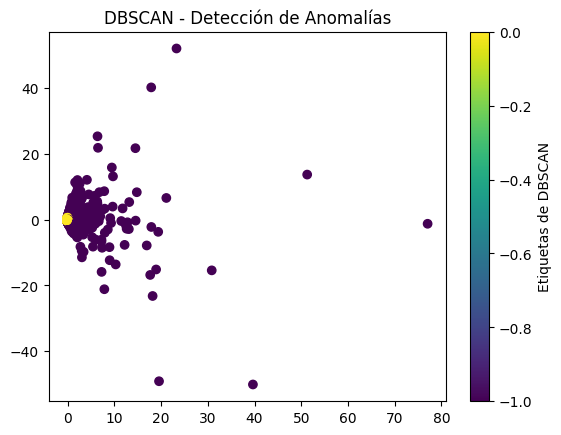

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(scaled_df_V2['Componente_1'],scaled_df_V2['Componente_2'], c=dbscan_labels, cmap='viridis')
plt.title('DBSCAN - Detección de Anomalías')
plt.colorbar(label='Etiquetas de DBSCAN')
plt.show()

In [ ]:
scaled_df_V2['CUENTA_ID_HASH'] = df_Agrupado.index

In [ ]:
Conjunto_0 = scaled_df_V2[scaled_df_V2['DBSCAN_Label']==0]
Conjunto_1 = scaled_df_V2[scaled_df_V2['DBSCAN_Label']==-1]
Lista_Cjto_0 = list(Conjunto_0['CUENTA_ID_HASH'])
Lista_Cjto_1 = list(Conjunto_1['CUENTA_ID_HASH'])

Regresaremos al conjunto inicial para hacer un analisis estadistico de ambos conjuntos

In [ ]:
Archivo_Fraude['Flag_Ctas_Anomalas'] = Archivo_Fraude['CUENTA_ID_HASH'].isin(Lista_Cjto_0).astype(int)
Transacciones_Cuentas_Cjto_1 = Archivo_Fraude[Archivo_Fraude['Flag_Ctas_Anomalas']==1]
Transacciones_Cuentas_Cjto_0 = Archivo_Fraude[Archivo_Fraude['Flag_Ctas_Anomalas']==0]

### 9- Analisis estadistico:

In [ ]:
Transacciones_Cuentas_Cjto_0['OCUPACION'].describe().round()

count       960845
unique           9
top       EMPLOYEE
freq        387644
Name: OCUPACION, dtype: object

In [ ]:
Transacciones_Cuentas_Cjto_1['OCUPACION'].describe().round()

count       497629
unique          10
top       EMPLOYEE
freq        280929
Name: OCUPACION, dtype: object

In [ ]:
Transacciones_Cuentas_Cjto_0['OCUPACION'].value_counts()/Transacciones_Cuentas_Cjto_0['OCUPACION'].value_counts().sum()

OCUPACION
EMPLOYEE                    0.403441
PARTNEROROWNER              0.188636
STUDENT                     0.112288
OWNBUSINESS                 0.078953
HOUSEKEEPER                 0.076393
MERCHANT                    0.058008
FREELANCER                  0.040708
SELFEMPLOYEDPROFESSIONAL    0.039587
RETIRED                     0.001986
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_1['OCUPACION'].value_counts()/Transacciones_Cuentas_Cjto_1['OCUPACION'].value_counts().sum()

OCUPACION
EMPLOYEE                    0.564535
STUDENT                     0.128019
HOUSEKEEPER                 0.074507
PARTNEROROWNER              0.056831
FREELANCER                  0.047612
OWNBUSINESS                 0.046350
SELFEMPLOYEDPROFESSIONAL    0.037456
MERCHANT                    0.034940
RETIRED                     0.008522
UNEMPLOYED                  0.001228
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_0['año_INICIO_RELACION'].value_counts()/Transacciones_Cuentas_Cjto_0['año_INICIO_RELACION'].value_counts().sum()

año_INICIO_RELACION
2022.0    0.547109
2023.0    0.311305
2024.0    0.141586
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_1['año_INICIO_RELACION'].value_counts()/Transacciones_Cuentas_Cjto_1['año_INICIO_RELACION'].value_counts().sum()

año_INICIO_RELACION
2022.0    0.428490
2023.0    0.299930
2024.0    0.268998
2025.0    0.002582
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_0['FLUJO'].value_counts()/Transacciones_Cuentas_Cjto_0['FLUJO'].value_counts().sum()

FLUJO
ENTRADAS    0.647492
SALIDAS     0.352508
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_1['FLUJO'].value_counts()/Transacciones_Cuentas_Cjto_1['FLUJO'].value_counts().sum()

FLUJO
ENTRADAS    0.583883
SALIDAS     0.416117
Name: count, dtype: float64

In [ ]:
Transacciones_Cuentas_Cjto_0['MOVIMIENTO'].value_counts()/Transacciones_Cuentas_Cjto_0['MOVIMIENTO'].value_counts().sum()

MOVIMIENTO
Ingreso por procesamiento de pagos                             0.365672
Pagos                                                          0.189257
Money in vía P2P                                               0.167240
Money out (Clabe)                                              0.129768
Money in vía transferencia (Clabe)                             0.102261
Money out vía P2P                                              0.024827
Fondeo Tarjeta de débito/Crédito                               0.008367
Pago con destino en Exchange                                   0.005546
Cash out ATM con Tarjeta MP                                    0.002729
Cash in                                                        0.001894
Ingreso de recursos con origen en Exchange                     0.001573
Cash out Comisionistas                                         0.000382
Remesas                                                        0.000285
Entrega de recursos provenientes de un transmisor de 

In [ ]:
Transacciones_Cuentas_Cjto_1['MOVIMIENTO'].value_counts()/Transacciones_Cuentas_Cjto_1['MOVIMIENTO'].value_counts().sum()

MOVIMIENTO
Money in vía P2P                                               0.419808
Pagos                                                          0.176772
Money out vía P2P                                              0.114997
Money in vía transferencia (Clabe)                             0.112139
Money out (Clabe)                                              0.111893
Fondeo Tarjeta de débito/Crédito                               0.023486
Ingreso por procesamiento de pagos                             0.021751
Pago con destino en Exchange                                   0.010773
Ingreso de recursos con origen en Exchange                     0.003719
Cash in                                                        0.002468
Cash out ATM con Tarjeta MP                                    0.001279
Cash out Comisionistas                                         0.000403
Entrega de recursos provenientes de un transmisor de dinero    0.000309
Remesas                                              

In [ ]:
Tabla_dinamica_transferencias_tot_Cjto_0 =  pd.pivot_table(Transacciones_Cuentas_Cjto_0,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Total_Monto'})
Tabla_dinamica_transferencias_mean_Cjto_0 =  pd.pivot_table(Transacciones_Cuentas_Cjto_0,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Media_Monto'})
Tabla_dinamica_transferencias_Rec_Cjto_0 =  pd.pivot_table(Transacciones_Cuentas_Cjto_0,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Rec_Trans'})
Tabla_dinamica_transferencias_max_Cjto_0 =  pd.pivot_table(Transacciones_Cuentas_Cjto_0,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'max',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Max_Monto'})
Tabla_dinamica_transferencias_min_Cjto_0 =  pd.pivot_table(Transacciones_Cuentas_Cjto_0,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'min',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Min_Monto'})

In [ ]:
Tabla_dinamica_transferencias_tot_Cjto_1 =  pd.pivot_table(Transacciones_Cuentas_Cjto_1,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'sum',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Total_Monto'})
Tabla_dinamica_transferencias_mean_Cjto_1 =  pd.pivot_table(Transacciones_Cuentas_Cjto_1,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'mean',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Media_Monto'})
Tabla_dinamica_transferencias_Rec_Cjto_1 =  pd.pivot_table(Transacciones_Cuentas_Cjto_1,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'count',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Rec_Trans'})
Tabla_dinamica_transferencias_max_Cjto_1 =  pd.pivot_table(Transacciones_Cuentas_Cjto_1,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'max',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Max_Monto'})
Tabla_dinamica_transferencias_min_Cjto_1 =  pd.pivot_table(Transacciones_Cuentas_Cjto_1,values='PAY_TOTAL_PAID_AMT',index='CUENTA_ID_HASH',aggfunc= 'min',dropna=False).rename(columns={'PAY_TOTAL_PAID_AMT':'Min_Monto'})

In [ ]:
Lista_DF = [Tabla_dinamica_transferencias_mean_Cjto_0,Tabla_dinamica_transferencias_Rec_Cjto_0,Tabla_dinamica_transferencias_max_Cjto_0,Tabla_dinamica_transferencias_min_Cjto_0]

df_Agrupado_Cjto_0 = Tabla_dinamica_transferencias_tot_Cjto_0

for i in range(0,len(Lista_DF)):
    df_Agrupado_Cjto_0 = pd.merge(df_Agrupado_Cjto_0, Lista_DF[i], on='CUENTA_ID_HASH', how='left')

In [ ]:
Lista_DF = [Tabla_dinamica_transferencias_mean_Cjto_1,Tabla_dinamica_transferencias_Rec_Cjto_1,Tabla_dinamica_transferencias_max_Cjto_1,Tabla_dinamica_transferencias_min_Cjto_1]

df_Agrupado_Cjto_1 = Tabla_dinamica_transferencias_tot_Cjto_1

for i in range(0,len(Lista_DF)):
    df_Agrupado_Cjto_1 = pd.merge(df_Agrupado_Cjto_1, Lista_DF[i], on='CUENTA_ID_HASH', how='left')

In [ ]:
df_Agrupado_Cjto_0.describe().round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto
count,2380.0,2380.0,2380.0,2380.0,2380.0
mean,431003.0,728.0,608.0,17138.0,2.0
std,1401360.0,1249.0,1456.0,47226.0,17.0
min,569.0,3.0,46.0,100.0,0.0
25%,84645.0,284.0,233.0,5000.0,0.0
50%,177292.0,482.0,327.0,9222.0,0.0
75%,365671.0,840.0,534.0,17448.0,0.0
max,27506481.0,40534.0,40289.0,1462200.0,489.0


In [ ]:
df_Agrupado_Cjto_1.describe().round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto
count,18821.0,11134.0,18821.0,11134.0,11134.0
mean,15599.0,695.0,28.0,3846.0,157.0
std,57599.0,2492.0,47.0,9207.0,824.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,145.0,0.0,506.0,0.0
50%,650.0,343.0,3.0,1399.0,0.0
75%,9968.0,701.0,34.0,4000.0,60.0
max,3808185.0,188197.0,242.0,500000.0,28782.0


In [ ]:
(100*(df_Agrupado_Cjto_1.describe().round(0) - df_Agrupado_Cjto_0.describe().round(0))/df_Agrupado_Cjto_0.describe()).round(0)

,Total_Monto,Media_Monto,Rec_Trans,Max_Monto,Min_Monto
count,691.0,368.0,691.0,368.0,368.0
mean,-96.0,-5.0,-95.0,-78.0,9839.0
std,-96.0,100.0,-97.0,-81.0,4708.0
min,-100.0,-111.0,-100.0,-100.0,0.0
25%,-100.0,-49.0,-100.0,-90.0,0.0
50%,-100.0,-29.0,-99.0,-85.0,0.0
75%,-97.0,-17.0,-94.0,-77.0,300000.0
max,-86.0,364.0,-99.0,-66.0,5786.0


Conclusiones:
* Solo se pudieron generar dos modelos con DB-Skan, el 0 (89% de las cuentas) y el 1 (11% de las cuentas). 
* La variable que mejor separa estos conjuntos es  el monto y la cantidad de transacciones generadas.
* El monto total del conjunto_1 es 96% mas bajo que el del conjunto_0.
* El numero de transacciones del conjunto_1 es 95% mas bajo que el del conjunto_0.
* En conclusion transfieren mas veces y mas dinero.